In [2]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

import sys
sys.path.append('..')
from sven.nn import SvenWrapper
from experiments.nn import MLP
from sven.opt import Sven

import copy

from experiments.experiment_code.experiment_utils import train_loop_standard, train_loop_svd, set_seed

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Using device: cuda


In [3]:
from torchvision import datasets, transforms
from experiments.datasets import MNISTDataset

digits = np.arange(10)
mnist = MNISTDataset(ROOT='./torch_datasets/',digits=digits)
train_dataset = mnist.train_dataset
test_dataset = mnist.val_dataset

In [4]:
set_seed(437438)
def get_model():
    return MLP(
        input_dim=784,
        hidden_dims=[32,32],
        output_dim=len(digits)
    )
mlp_base = get_model()
init_state = copy.deepcopy(mlp_base.state_dict())
del mlp_base # free memory

In [19]:
LOADER_SEED = 645297
batch_size = 64
n_epoch = 10
K = 64
RTOL = 1e-8
LR = 1e-3
LR_SVD = 0.5

### Train MLP with Adam

In [13]:
model_adam = get_model()
model_adam.load_state_dict(init_state)
model_adam = model_adam.to(device)

optimizer = torch.optim.Adam(model_adam.parameters(), lr=LR)
def loss_fn(pred,y):
    #y = F.one_hot(y, num_classes=len(digits)).to(pred)
    #return (pred - y).pow(2).sum(dim=1).mean()
    return F.cross_entropy(pred, y, reduction='mean')

train_loader = DataLoader(mnist.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(mnist.val_dataset, batch_size=256, shuffle=False)

model_adam, losses_adam = train_loop_standard(model_adam, optimizer, loss_fn, train_loader, test_loader, n_epoch, device, track_acc=True)

Using device cuda


100%|██████████| 10/10 [00:44<00:00,  4.49s/it]


### Train MLP with Sven

In [20]:
if device == torch.device('mps'):
    device = torch.device('cpu')
model_svd = get_model()
model_svd.load_state_dict(init_state)
model_svd = model_svd.to(device)

def loss_fn(pred,y):
    #y = F.one_hot(y, num_classes=len(digits)).to(pred)
    #return (pred - y).pow(2).sum(dim=1)
    return F.cross_entropy(pred, y, reduction='none')


model_svd = SvenWrapper(model_svd, loss_fn, device=device)
optimizer = Sven(model_svd,lr=LR_SVD,k=K,rtol=RTOL,track_svd_info=True,svd_mode='torch', use_rmsprop=False)

train_loader = DataLoader(mnist.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(mnist.val_dataset, batch_size=256, shuffle=False)

model_svd, losses_svd, optimizer = train_loop_svd(model_svd,optimizer,loss_fn,train_loader,test_loader,n_epoch,device,track_acc=True)
svd_info = optimizer.svd_info

100%|██████████| 10/10 [02:27<00:00, 14.77s/it]


### compare all three

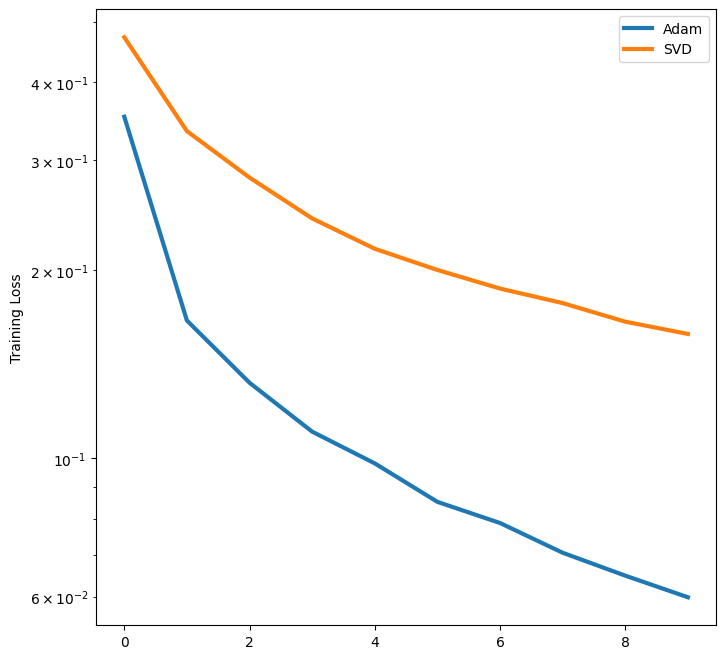

In [22]:
plt.figure(figsize=(8,8))
plt.plot(losses_adam['train'],label='Adam',lw=3)
plt.plot(losses_svd['train'],label='SVD',lw=3)
plt.legend()
plt.ylabel("Training Loss")
plt.yscale('log')

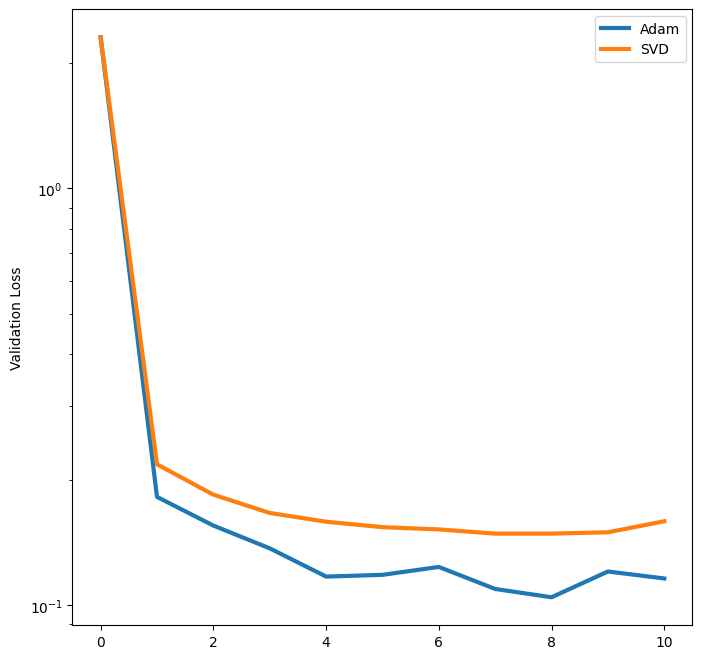

In [15]:
plt.figure(figsize=(8,8))
plt.plot(losses_adam['val'],label='Adam',lw=3)
plt.plot(losses_svd['val'],label='SVD',lw=3)
plt.legend()
plt.ylabel("Validation Loss")
plt.yscale('log')